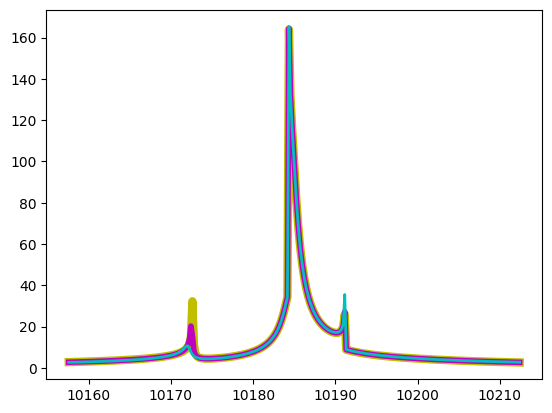

In [53]:
import VBMicrolensing
import math
import numpy as np
import matplotlib.pyplot as plt

VBM = VBMicrolensing.VBMicrolensing()
VBM.parallaxsystem = 1       # Set parallax system to North-East
VBM.SetObjectCoordinates( "17:57:38.03 -28:38:28.53") # Assign RA and Dec to our microlensing event
VBM.t0_par = 10063.874

tE = 68.5053
rho = 8.96025e-05
s = 0.950001
piEN = 0.128858
piEE = 0.136441
gamma1 = -0.00137559
gamma2 = 0.00149516
gamma3 = -0.00188781
rs = 0.000133878
a_s = 1.07743
t0 = 10090 - 5+100
u0 = 0.01          
q = 0.005
alpha = 3.7*np.pi/4

pr = [math.log(s), math.log(q), u0, alpha, math.log(rho), math.log(tE), t0, piEN, piEE, gamma1, gamma2, gamma3,rs,a_s]
t = np.linspace(t0-0.4*tE, t0+0.4*tE, 300) # Array of times
magnifications, y1, y2 = VBM.BinaryLightCurve(pr,t)      #
magnificationspar, y1par, y2par = VBM.BinaryLightCurveParallax(pr,t)      # Calculation of light curve with parallax
magnificationsorb, y1orb, y2orb, sorb = VBM.BinaryLightCurveKepler(pr,t)      # Calculation of light curve with orbital motion
plt.plot(t,magnificationsorb,"y",lw=6)

pr2 = [math.log(s), math.log(q), u0, alpha, math.log(rho), math.log(tE), t0+100, piEN, piEE, gamma1, gamma2, gamma3,rs,a_s]
t2= np.linspace(t0+100-0.4*tE, t0+100+0.4*tE, 300) 
magnifications, y1, y2 = VBM.BinaryLightCurve(pr2,t2)      #
magnificationspar, y1par, y2par = VBM.BinaryLightCurveParallax(pr2,t2) 
magnificationsorb2, y1orb2, y2orb2, sorb2 = VBM.BinaryLightCurveKepler(pr2,t2)    

plt.plot(t2-100,magnificationsorb2,"m",lw=4)


pr3 = [math.log(s), math.log(q), u0, alpha, math.log(rho), math.log(tE), t0+150, piEN, piEE, gamma1, gamma2, gamma3,rs,a_s]
t3 = np.linspace(t0+150-0.4*tE, t0+150+0.4*tE, 300) 
magnifications, y1, y2 = VBM.BinaryLightCurve(pr3,t3)      #
magnificationspar, y1par, y2par = VBM.BinaryLightCurveParallax(pr3,t3) 
magnificationsorb3, y1orb3, y2orb3, sorb3 = VBM.BinaryLightCurveKepler(pr3,t3)    

plt.plot(t3-150,magnificationsorb3,"c",lw=2)

plt.show()

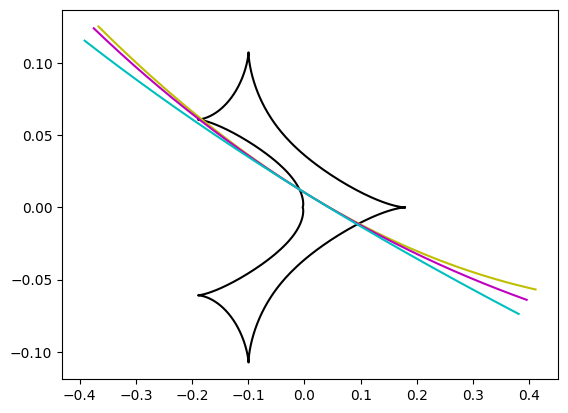

In [51]:
caustictimes = [100,150,200]
colors = [(0,0,1,1),(0.4,0,0.6,1),(0.6,0,0.4,1)]
for i in range(1,2):
    caustics = VBM.Caustics(sorb[caustictimes[i]],q)
    for cau in caustics:
        plt.plot(cau[0],cau[1],color = "k")

plt.plot(y1orb,y2orb,"y")
plt.plot(y1orb2,y2orb2,"m")
plt.plot(y1orb3,y2orb3,"c")

plt.show()